<h1 align="center">Life Satisfaction Prediction using GDP per Capita</h1>

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

import warnings
warnings.filterwarnings("ignore")

## Part 1: Data Exploration and Visualization

#### **Q1 (5 marks)** Load the dataset `lifesat.csv` and display first 5 rows

In [4]:
df = pd.read_csv("lifesat.csv")
df.head()

,Country,GDP per capita (USD),Life satisfaction
0,Russia,26456.387938,5.8
1,Greece,27287.083401,5.4
2,Turkey,28384.987785,5.5
3,Latvia,29932.493910,5.9
4,Hungary,31007.768407,5.6


##### **Q2 (5 marks)** Print basic `info` and `summary statistics`

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               27 non-null     object 
 1   GDP per capita (USD)  27 non-null     float64
 2   Life satisfaction     27 non-null     float64
dtypes: float64(2), object(1)
memory usage: 780.0+ bytes


In [9]:
df.describe()

,GDP per capita (USD),Life satisfaction
count,27.000000,27.000000
mean,41564.521771,6.566667
std,9631.452319,0.765607
min,26456.387938,5.400000
25%,33938.289305,5.900000
50%,41627.129269,6.800000
75%,49690.580269,7.300000
max,60235.728492,7.600000


#### **Q3 (10 marks)** Display a scatter plot for `GPD per capita` vs `Life Satisfaction`. And labels, title, and discuss the observed relationship.

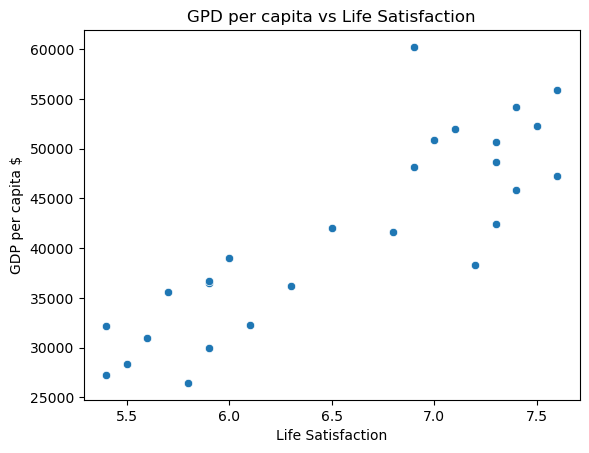

In [17]:
plt.title("GPD per capita vs Life Satisfaction")
sns.scatterplot(x='Life satisfaction', y='GDP per capita (USD)', data=df)
plt.xlabel("Life Satisfaction")
plt.ylabel("GDP per capita $")
plt.show()

##### **Discuss the observation relationship**

We have positive correlation betweem `GDP per capita` and `Life Satisfaction`, so we can draw a line.

## Part 2: Linear Regression Model

#### **Q4 (5 marks)** Extract input (X) and target (y). Print their shapes.

In [28]:
X = df[['GDP per capita (USD)']]
y = df[['Life satisfaction']]
print(X.shape, y.shape)

(27, 1) (27, 1)


#### **Q5 (10 marks)** Train a Linear Regression model & Display Cofficient and intercept

In [30]:
model = LinearRegression()
model.fit(X, y)

print("Coefficient (slope)", model.coef_[0])
print("Intercept", model.intercept_)

Coefficient (slope) [6.77889969e-05]
Intercept [3.74904943]


#### **Q6 (10 marks)** Plot the predicted regression line from the model along with a scatter plot of the data

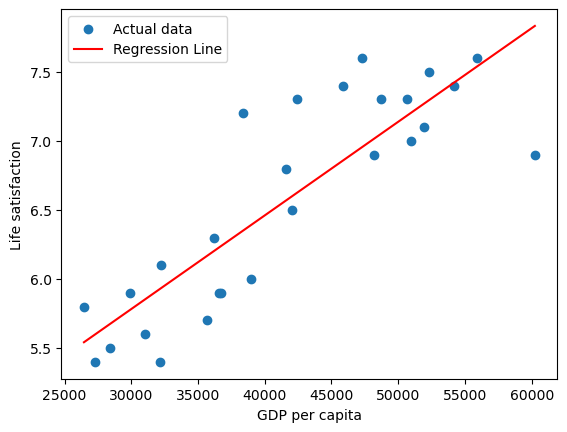

In [38]:
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred = model.predict(X_range)

plt.scatter(X, y, label="Actual data")
plt.plot(X_range, y_pred, color='red', label="Regression Line")

plt.xlabel("GDP per capita")
plt.ylabel("Life satisfaction")
plt.legend()
plt.show()

#### **Q7 (5 marks)** Predict Life Satisfaction per GDP = 37,655.2 USD. Comment on result

In [40]:
GDP = [[37_655.2]]
prediction = model.predict(GDP)

print("Predicted Life Satisfaction:", prediction[0])

Predicted Life Satisfaction: [6.30165767]


The predicted `Life Satisfaction` for `GDP = 37,655.2` is approximately `6.30165767`.

## Part 3: K-Neares Neighbors Regression

#### **Q8 (5 marks)** Train a KNeighborsRegression (n_neighbors = 3)

In [43]:
knn = KNeighborsRegressor(n_neighbors = 3)
knn.fit(X, y)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


#### **Q9 (10 marks)**
- Predict Life Satisfaction for GDP = 37,655.2 USD
- Compare with Linear Regression

In [44]:
knn_prediction = knn.predict(GDP)
print("Predicted by 3 neighbors:", knn_prediction[0])

Predicted by 3 neighbors: [6.33333333]


Compared `KNN` with `Linear Regression` we can assume that there aren't big difference between predected result. The spread was `~0.03` of `Life Satisfaction Level`.

#### **Q10 (10 marks)**
- Use n_neighbors 1, 3, 5 and 10 and print the predicted values of life satisfaction
- Plot the results using a line plot.

In [47]:
knn1 = KNeighborsRegressor(n_neighbors = 1)
knn5 = KNeighborsRegressor(n_neighbors = 5)
knn10 = KNeighborsRegressor(n_neighbors = 10)

knn1.fit(X, y)
knn5.fit(X, y)
knn10.fit(X, y)

print("Predicted by 1 neighbor:", knn1.predict(GDP)[0])
print("Predicted by 3 neighbors:", knn.predict(GDP)[0])
print("Predicted by 5 neighbors:", knn5.predict(GDP)[0])
print("Predicted by 10 neighbors:", knn10.predict(GDP)[0])

Predicted by 1 neighbor: [7.2]
Predicted by 3 neighbors: [6.33333333]
Predicted by 5 neighbors: [6.26]
Predicted by 10 neighbors: [6.37]


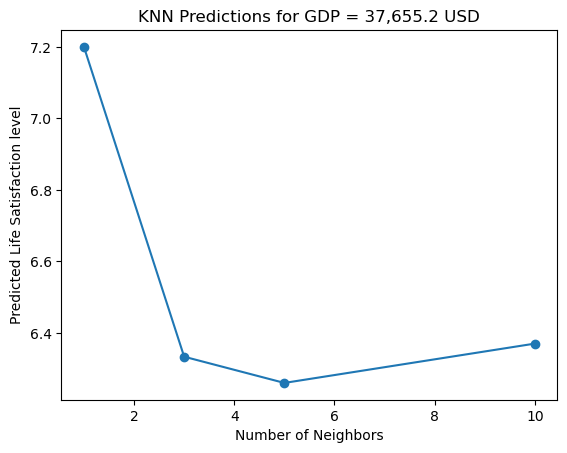

In [50]:
neighbors = [1, 3, 5, 10]
predictions = [7.2, 6.33333333, 6.26, 6.37]

plt.plot(neighbors, predictions, marker='o')
plt.xlabel("Number of Neighbors")
plt.ylabel("Predicted Life Satisfaction level")
plt.title("KNN Predictions for GDP = 37,655.2 USD")
plt.show()